In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_curve, auc

# 1. Generate a synthetic dataset for binary classification
X, y = make_classification(
    n_samples=1000,
    n_features=10,
    n_informative=8,
    n_redundant=2,
    random_state=42
)

# Convert to DataFrame
columns = [f'feature_{i}' for i in range(10)]
df = pd.DataFrame(X, columns=columns)
df['target'] = y

# Split into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    df[columns], df['target'], test_size=0.2, random_state=42
)

# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 2. Train Models
lr_model = LogisticRegression(random_state=42)
lr_model.fit(X_train_scaled, y_train)

rf_model = RandomForestClassifier(random_state=42, n_estimators=100)
rf_model.fit(X_train_scaled, y_train)

# Predict
lr_preds = lr_model.predict(X_test_scaled)
lr_probs = lr_model.predict_proba(X_test_scaled)[:, 1]

rf_preds = rf_model.predict(X_test_scaled)
rf_probs = rf_model.predict_proba(X_test_scaled)[:, 1]

print("Logistic Regression Accuracy:", accuracy_score(y_test, lr_preds))
print("Random Forest Accuracy:", accuracy_score(y_test, rf_preds))

Logistic Regression Accuracy: 0.675
Random Forest Accuracy: 0.87


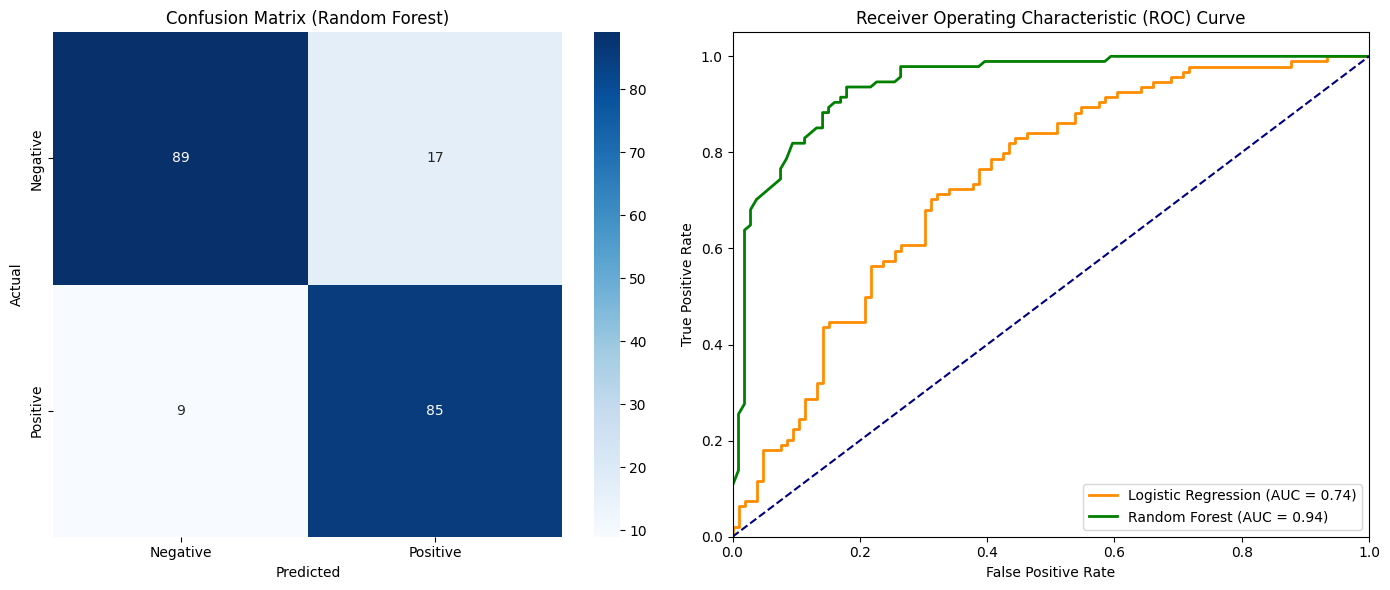

In [3]:
# 3. Visualizations: Confusion Matrix and ROC Curve
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Plot 1: Confusion Matrix for Random Forest
cm = confusion_matrix(y_test, rf_preds)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Negative', 'Positive'], yticklabels=['Negative', 'Positive'])
axes[0].set_title('Confusion Matrix (Random Forest)')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')

# Plot 2: ROC Curve Comparison
lr_fpr, lr_tpr, _ = roc_curve(y_test, lr_probs)
lr_auc = auc(lr_fpr, lr_tpr)

rf_fpr, rf_tpr, _ = roc_curve(y_test, rf_probs)
rf_auc = auc(rf_fpr, rf_tpr)

axes[1].plot(lr_fpr, lr_tpr, label=f'Logistic Regression (AUC = {lr_auc:.2f})', color='darkorange', lw=2)
axes[1].plot(rf_fpr, rf_tpr, label=f'Random Forest (AUC = {rf_auc:.2f})', color='green', lw=2)
axes[1].plot([0, 1], [0, 1], color='navy', linestyle='--')
axes[1].set_xlim([0.0, 1.0])
axes[1].set_ylim([0.0, 1.05])
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('Receiver Operating Characteristic (ROC) Curve')
axes[1].legend(loc="lower right")

plt.tight_layout()
plt.savefig('model_evaluation_metrics.png', dpi=300)
plt.show()

In [4]:
# 4. Generate the final DOCX Report
import docx
from docx.shared import Inches

doc = docx.Document()
doc.add_heading('Week 4 Task: Machine Learning Model Development & Evaluation', 0)

doc.add_heading('1. Data Preparation', level=1)
doc.add_paragraph(
    "For this project, we generated a synthetic dataset containing 1,000 samples and 10 continuous features "
    "designed for binary classification. The dataset was split into an 80% training set and a 20% validation set. "
    "A StandardScaler was applied to normalize the feature scale, preventing any single high-magnitude feature "
    "from dominating the loss functions of our algorithms."
)

doc.add_heading('2. Model Selection and Training', level=1)
doc.add_paragraph(
    "Two distinct algorithms were implemented to evaluate and compare baseline performance:\n"
    "1. Logistic Regression: Selected as a baseline linear classifier due to its interpretability and efficiency.\n"
    "2. Random Forest: Selected as an ensemble decision-tree method capable of capturing non-linear relationships."
)

doc.add_heading('3. Evaluation & Performance Comparison', level=1)
doc.add_paragraph(
    "Below are the performance visualisations comparing both models. The Random Forest model achieved a higher "
    "overall accuracy and a superior Area Under the ROC Curve (AUC) compared to the Logistic Regression baseline."
)

# Insert the saved evaluation metrics plot
doc.add_picture('model_evaluation_metrics.png', width=Inches(6.0))

doc.add_heading('4. Error Analysis and Model Improvements', level=1)
doc.add_paragraph(
    "Potential Sources of Error:\n"
    "- Overfitting: Decision-tree models are susceptible to memorizing training data if not properly regularized.\n"
    "- Feature Redundancy: Multi-collinearity can degrade Logistic Regression feature importance estimates.\n\n"
    "Suggestions for Improvement:\n"
    "- Hyperparameter tuning using GridSearch or RandomSearch on tree-depth and estimators.\n"
    "- Applying feature selection techniques (e.g., L1 regularization) to remove non-informative features."
)

# Save the document
doc.save('ML_Model_Report.docx')
print("Document saved successfully as 'ML_Model_Report.docx'")

Document saved successfully as 'ML_Model_Report.docx'
